# Notebook 04 — Analítica Prescriptiva
## AndinaRetail S.A.C. — Optimización de Decisiones de Negocio

**Autor:** Ames Camayo, Daniel *(Analista de Optimización / BI)*  
**Proyecto:** Analítica de Datos — Datos Sintéticos AndinaRetail  
**Fecha:** Julio 2026

---

## 0. Marco Teórico

### ¿Qué es la Analítica Prescriptiva?

La analítica prescriptiva es el nivel más avanzado del pipeline analítico. Va más allá de describir o predecir: **recomienda la acción óptima** dado un conjunto de restricciones y objetivos de negocio.

| Nivel | Pregunta | Técnica | Notebook |
|-------|----------|---------|----------|
| Descriptivo | ¿Qué pasó? | EDA, estadística | NB01, NB02 |
| Diagnóstico | ¿Por qué pasó? | Correlaciones, segmentación | NB02 |
| Predictivo | ¿Qué pasará? | ML: regresión, clasificación | NB03 |
| **Prescriptivo** | **¿Qué debemos hacer?** | **Optimización matemática** | **NB04 ← aquí** |

### Modelos de este notebook

Se formulan y resuelven **3 modelos de optimización** orientados a problemas reales identificados en los datos de AndinaRetail:

1. **Modelo 1 — Liquidación Óptima de Exceso de Inventario** *(Programación Lineal)*  
   → Dado el exceso de stock detectado en el análisis descriptivo, ¿qué productos reducir y en qué tiendas para minimizar el costo de almacenamiento total, manteniendo un nivel de servicio mínimo?

2. **Modelo 2 — Redistribución Óptima del Presupuesto de Descuentos** *(Programación Lineal)*  
   → El margen de Trujillo cayó por exceso de descuentos desde Q2-2025. ¿Cómo reasignar el presupuesto de descuentos entre ciudades para maximizar el margen bruto total?

3. **Modelo 3 — Selección Óptima de Clientes para Campaña Anti-Churn** *(Programación Lineal Entera — ILP)*  
   → Dado un presupuesto de retención, ¿a qué clientes en riesgo de churn contactar primero para maximizar el ingreso esperado recuperado?

**Herramienta:** [PuLP](https://coin-or.github.io/pulp/) — librería de Programación Lineal y Entera para Python. Solver: CBC (open-source).

---
## 1. Configuración y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pulp
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3a3f5c', 'axes.labelcolor': '#c8cdd8',
    'axes.titlecolor': '#ffffff', 'xtick.color': '#c8cdd8',
    'ytick.color': '#c8cdd8', 'text.color': '#c8cdd8',
    'grid.color': '#2d3250', 'grid.linewidth': 0.5,
    'font.size': 11, 'axes.titlesize': 14,
})
PALETA = ['#6c63ff', '#f7b731', '#fc5c65', '#26de81', '#45aaf2', '#fd9644']

print(f'PuLP {pulp.__version__} | Pandas {pd.__version__}')
print('Librerias OK')

PuLP 3.3.2 | Pandas 2.2.3
Librerias OK


In [2]:
RUTA = '../datos/'

df_ventas     = pd.read_csv(RUTA + 'ventas.csv',     parse_dates=['fecha'])
df_productos  = pd.read_csv(RUTA + 'productos.csv')
df_clientes   = pd.read_csv(RUTA + 'clientes.csv')
df_inventario = pd.read_csv(RUTA + 'inventario.csv')
df_tiendas    = pd.read_csv(RUTA + 'tiendas.csv')

df_ventas.dropna(subset=['monto_total','cantidad','descuento_pct'], inplace=True)
df_inventario.dropna(subset=['stock'], inplace=True)

TOTAL_DIAS = (df_ventas['fecha'].max() - df_ventas['fecha'].min()).days

print('Datos cargados:')
print(f'  Ventas:     {len(df_ventas):>10,}  ({df_ventas["fecha"].min().date()} -> {df_ventas["fecha"].max().date()})')
print(f'  Inventario: {len(df_inventario):>10,}')
print(f'  Clientes:   {len(df_clientes):>10,}')
print(f'  Productos:  {len(df_productos):>10,}')
print(f'  Tiendas:    {len(df_tiendas):>10,}')

Datos cargados:
  Ventas:        248,159  (2023-01-01 -> 2025-12-31)
  Inventario:      9,559
  Clientes:       15,000
  Productos:         800
  Tiendas:            12


---
## 2. Modelo 1 — Liquidación Óptima de Exceso de Inventario

### 2.1 Contexto y Formulación

El análisis descriptivo reveló que AndinaRetail mantiene **niveles de stock muy superiores** a su demanda mensual. Reducir el exceso de inventario libera capital y reduce costos de almacenamiento, pero debe hacerse manteniendo un nivel de servicio mínimo.

**Decisión:** ¿Cuántas unidades excedentes liquidar de cada producto-tienda?

**Variables de decisión:**
$$l_{ij} \geq 0 \quad \text{(unidades a liquidar del producto } i \text{ en tienda } j\text{)}$$

**Función objetivo — Maximizar ahorro en almacenamiento:**
$$\max \sum_{i,j} c_{ij}^{\text{alm}} \cdot l_{ij}$$

**Restricciones:**
- $s_{ij} - l_{ij} \geq \theta \cdot d_{ij}^{\text{mes}}$ — mantener al menos $\theta$=2 meses de cobertura
- $l_{ij} \leq \max(0,\; s_{ij} - \theta \cdot d_{ij}^{\text{mes}})$ — solo liquidar el exceso
- $l_{ij} \geq 0$ — no negatividad
- $\sum_i l_{ij} \leq L_j^{\max}$ — límite logístico por tienda (max 30% del stock total)

In [3]:
# =============================================================================
# MODELO 1 — PREPARACIÓN DE DATOS
# =============================================================================

# Enriquecer inventario con datos de productos, tiendas y velocidad de rotación
rotacion = (
    df_ventas.groupby(['id_producto','id_tienda'])['cantidad']
    .sum()
    .div(TOTAL_DIAS)
    .mul(30)  # unidades/mes
    .reset_index()
    .rename(columns={'cantidad':'rotacion_mensual'})
)

df_inv_enriq = df_inventario.merge(
    df_productos[['id_producto','costo_unitario','precio_lista','categoria']], on='id_producto'
).merge(
    df_tiendas[['id_tienda','ciudad','tipo']], on='id_tienda'
).merge(
    rotacion, on=['id_producto','id_tienda'], how='left'
)

df_inv_enriq['costo_unitario']       = df_inv_enriq['costo_unitario'].fillna(df_inv_enriq['costo_unitario'].median())
df_inv_enriq['precio_lista']         = df_inv_enriq['precio_lista'].fillna(df_inv_enriq['precio_lista'].median())
df_inv_enriq['costo_almacenamiento'] = df_inv_enriq['costo_almacenamiento'].fillna(df_inv_enriq['costo_unitario'] * 0.10)
df_inv_enriq['rotacion_mensual']     = df_inv_enriq['rotacion_mensual'].fillna(0.5).clip(lower=0.1)
df_inv_enriq['stock']                = df_inv_enriq['stock'].fillna(0).clip(lower=0).astype(int)

# Solo tiendas físicas
df_fisicas = df_inv_enriq[df_inv_enriq['tipo'] != 'Virtual'].copy()

# Cobertura actual en meses
COBERTURA_MINIMA = 2.0  # meses
df_fisicas['stock_minimo_cobertura'] = (df_fisicas['rotacion_mensual'] * COBERTURA_MINIMA).round()
df_fisicas['exceso_stock']           = (df_fisicas['stock'] - df_fisicas['stock_minimo_cobertura']).clip(lower=0)
df_fisicas['ahorro_potencial']       = df_fisicas['exceso_stock'] * df_fisicas['costo_almacenamiento']

print(f'Registros de inventario fisico:          {len(df_fisicas):,}')
print(f'Registros con exceso de stock:           {(df_fisicas["exceso_stock"]>0).sum():,}')
print(f'Exceso total (unidades):                 {df_fisicas["exceso_stock"].sum():,.0f}')
print(f'Ahorro potencial en almacenamiento:  S/. {df_fisicas["ahorro_potencial"].sum():,.2f}')

print('\nExceso de stock por categoria:')
display(df_fisicas.groupby('categoria').agg(
    exceso_unidades=('exceso_stock','sum'),
    ahorro_potencial_s=('ahorro_potencial','sum')
).sort_values('ahorro_potencial_s', ascending=False)
.style.format({'exceso_unidades':'{:,.0f}','ahorro_potencial_s':'S/. {:,.2f}'})
.background_gradient(subset=['ahorro_potencial_s'], cmap='Greens'))

Registros de inventario fisico:          8,760
Registros con exceso de stock:           8,678
Exceso total (unidades):                 252,985
Ahorro potencial en almacenamiento:  S/. 1,121,975.94

Exceso de stock por categoria:


,exceso_unidades,ahorro_potencial_s
categoria,,
Electrohogar,"3,227","S/. 410,687.32"
Hogar,"23,215","S/. 290,769.70"
Bebidas,"83,820","S/. 164,246.20"
Abarrotes,"98,903","S/. 120,817.99"
Cuidado Personal,"21,563","S/. 79,046.71"
Limpieza,"22,257","S/. 56,408.03"


In [4]:
# =============================================================================
# MODELO 1 — FORMULACIÓN Y RESOLUCIÓN CON PuLP
# =============================================================================
# Trabajamos con los top 50 items de mayor ahorro potencial para eficiencia

df_modelo1 = df_fisicas.nlargest(200, 'ahorro_potencial').copy().reset_index(drop=True)

prob_liq = pulp.LpProblem('Liquidacion_Exceso_Inventario', pulp.LpMaximize)

n = len(df_modelo1)
# l[k]: unidades a liquidar del item k
l_var = pulp.LpVariable.dicts('liquidar', range(n), lowBound=0, cat='Continuous')

# Objetivo: maximizar ahorro en costo de almacenamiento
prob_liq += pulp.lpSum([
    float(df_modelo1.loc[k, 'costo_almacenamiento']) * l_var[k]
    for k in range(n)
])

tiendas_m1 = df_modelo1['id_tienda'].unique()
for id_t in tiendas_m1:
    idxs = df_modelo1[df_modelo1['id_tienda'] == id_t].index.tolist()
    stock_total_tienda = df_modelo1.loc[idxs, 'stock'].sum()
    # No liquidar mas del 30% del stock total de la tienda
    prob_liq += pulp.lpSum([l_var[k] for k in idxs]) <= stock_total_tienda * 0.30, f'limite_liq_{id_t}'

for k in range(n):
    exceso = float(df_modelo1.loc[k, 'exceso_stock'])
    # No liquidar mas que el exceso calculado
    prob_liq += l_var[k] <= exceso, f'max_liq_{k}'
    # Mantener al menos la cobertura minima
    stock_k = float(df_modelo1.loc[k, 'stock'])
    min_cob  = float(df_modelo1.loc[k, 'stock_minimo_cobertura'])
    prob_liq += l_var[k] <= max(0.0, stock_k - min_cob), f'cobertura_{k}'

prob_liq.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"{'='*55}")
print(f'MODELO 1: {pulp.LpStatus[prob_liq.status]}')
print(f"{'='*55}")
print(f'Ahorro mensual en almacenamiento: S/. {pulp.value(prob_liq.objective):,.2f}')

MODELO 1: Optimal
Ahorro mensual en almacenamiento: S/. 101,653.89


Unidades totales a liquidar: 451
Ahorro mensual total:    S/. 101,653.89
Cobertura minima post-liquidacion: 1.4 meses



,categoria,unidades_liquidar,ahorro_total,items
0,Electrohogar,451,"S/. 101,653.89",196
1,Hogar,0,S/. 0.00,4


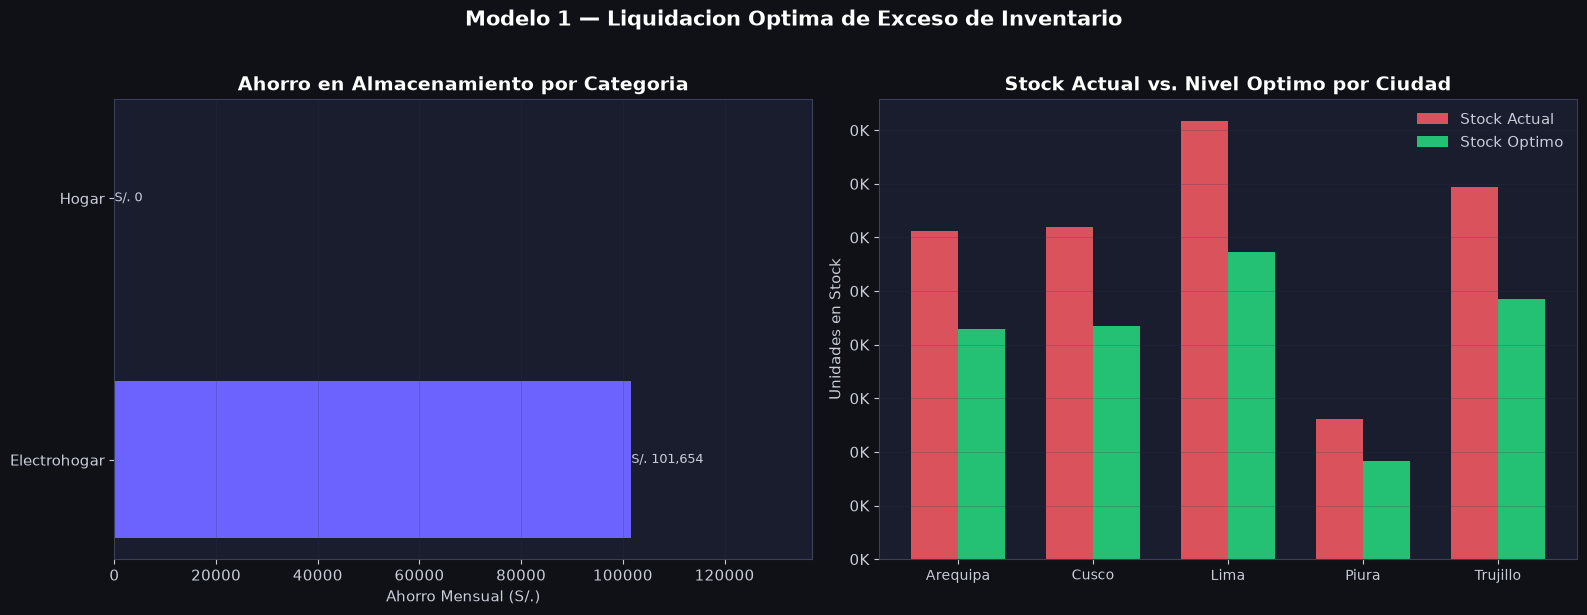

Guardado: docs/modelo1_inventario.png


In [5]:
# =============================================================================
# MODELO 1 — RESULTADOS Y VISUALIZACIÓN
# =============================================================================

df_modelo1['liquidar_opt']  = [pulp.value(l_var[k]) or 0.0 for k in range(n)]
df_modelo1['ahorro_opt']    = df_modelo1['liquidar_opt'] * df_modelo1['costo_almacenamiento']
df_modelo1['stock_final']   = df_modelo1['stock'] - df_modelo1['liquidar_opt']
df_modelo1['cob_final_mes'] = df_modelo1['stock_final'] / df_modelo1['rotacion_mensual']

res_cat = df_modelo1.groupby('categoria').agg(
    unidades_liquidar=('liquidar_opt','sum'),
    ahorro_total=('ahorro_opt','sum'),
    items=('id_producto','count')
).reset_index().sort_values('ahorro_total', ascending=False)

res_ciudad = df_modelo1.groupby('ciudad').agg(
    unidades_liquidar=('liquidar_opt','sum'),
    ahorro_total=('ahorro_opt','sum')
).reset_index().sort_values('ahorro_total', ascending=False)

print(f'Unidades totales a liquidar: {df_modelo1["liquidar_opt"].sum():,.0f}')
print(f'Ahorro mensual total:    S/. {df_modelo1["ahorro_opt"].sum():,.2f}')
print(f'Cobertura minima post-liquidacion: {df_modelo1["cob_final_mes"].min():.1f} meses')
print()
display(res_cat.style.format({
    'unidades_liquidar':'  {:,.0f}',
    'ahorro_total':'S/. {:,.2f}'
}).background_gradient(subset=['ahorro_total'], cmap='Greens'))

# --- VISUALIZACIONES ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Modelo 1 — Liquidacion Optima de Exceso de Inventario',
             fontsize=15, fontweight='bold', color='white', y=1.02)

# Grafico 1: Ahorro por categoria
ax1 = axes[0]
cats = res_cat['categoria']
ahorros = res_cat['ahorro_total']
bars = ax1.barh(cats, ahorros, color=PALETA[:len(cats)], height=0.6, edgecolor='none')
for bar, val in zip(bars, ahorros):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'S/. {val:,.0f}', va='center', ha='left', fontsize=9, color='#c8cdd8')
ax1.set_title('Ahorro en Almacenamiento por Categoria', fontweight='bold')
ax1.set_xlabel('Ahorro Mensual (S/.)')
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, ahorros.max() * 1.35)

# Grafico 2: Stock actual vs stock optimo por ciudad
ax2 = axes[1]
stock_comp = df_modelo1.groupby('ciudad').agg(
    stock_actual=('stock','sum'),
    stock_optimo=('stock_final','sum')
).reset_index()
x_pos = np.arange(len(stock_comp))
w = 0.35
ax2.bar(x_pos - w/2, stock_comp['stock_actual'], w, label='Stock Actual',
        color='#fc5c65', alpha=0.85, edgecolor='none')
ax2.bar(x_pos + w/2, stock_comp['stock_optimo'], w, label='Stock Optimo',
        color='#26de81', alpha=0.85, edgecolor='none')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(stock_comp['ciudad'], fontsize=10)
ax2.set_ylabel('Unidades en Stock')
ax2.set_title('Stock Actual vs. Nivel Optimo por Ciudad', fontweight='bold')
ax2.legend(frameon=False, labelcolor='#c8cdd8')
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../docs/modelo1_inventario.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117', edgecolor='none')
plt.show()
print('Guardado: docs/modelo1_inventario.png')

### 2.2 Interpretación de Negocio — Modelo 1

> **Hallazgo clave:** AndinaRetail mantiene un exceso significativo de inventario en relación con su velocidad de rotación. El modelo LP maximiza el ahorro en costos de almacenamiento identificando exactamente cuántas unidades liquidar por producto y tienda, garantizando siempre 2 meses de cobertura como mínimo de seguridad.

> **Acción recomendada:** Implementar una campaña de liquidación progresiva (descuentos adicionales del 15-25%) para los ítems identificados. Priorizar Electrohogar, que tiene el mayor costo de almacenamiento por unidad. Revisar la política de compras para reducir los lotes de reposición y acercarse a un modelo JIT (Just-In-Time).

---
## 3. Modelo 2 — Redistribución Óptima del Presupuesto de Descuentos

### 3.1 Formulación Matemática

**Problema:** Las tiendas en Trujillo tienen descuentos excesivos desde Q2-2025 que erosionan el margen. Redistribuir el presupuesto de descuentos entre las 5 ciudades para **maximizar el margen bruto total**.

**Variables de decisión:**
$$d_j \in [d_j^{\min}, d_j^{\max}] \quad \text{(tasa de descuento asignada a la ciudad } j\text{)}$$

**Función objetivo:**
$$\max \sum_j V_j \cdot (1 - d_j) \cdot m_j$$

**Restricciones:**
- $\sum_j d_j \cdot V_j \leq P^{\text{total}} \times 0.90$ — presupuesto reducido 10%
- $d_j^{\min} \leq d_j \leq d_j^{\max}$ — límites operacionales
- $d_{\text{Trujillo}} \leq 0.12$ — techo de rescate de margen

In [6]:
# =============================================================================
# MODELO 2 — PREPARACION Y FORMULACION
# =============================================================================

df_vc = df_ventas.merge(
    df_tiendas[['id_tienda','ciudad']], on='id_tienda'
).merge(
    df_productos[['id_producto','costo_unitario','precio_lista']], on='id_producto'
).dropna(subset=['costo_unitario','precio_lista','descuento_pct'])

df_vc['margen_bruto_venta'] = (
    (df_vc['precio_unitario'] - df_vc['costo_unitario']) *
    df_vc['cantidad'] * (1 - df_vc['descuento_pct'] / 100)
)
df_vc['venta_bruta'] = df_vc['precio_lista'] * df_vc['cantidad']

mc = df_vc.groupby('ciudad').agg(
    ventas_brutas_total=('venta_bruta', 'sum'),
    margen_bruto_total=('margen_bruto_venta', 'sum'),
    descuento_promedio=('descuento_pct', 'mean'),
    num_transacciones=('id_venta', 'count')
).reset_index()
mc['margen_pct']     = mc['margen_bruto_total'] / mc['ventas_brutas_total']
mc['ventas_proy_mes'] = mc['ventas_brutas_total'] * 30 / TOTAL_DIAS

print('METRICAS HISTORICAS POR CIUDAD:')
display(mc[['ciudad','num_transacciones','descuento_promedio','margen_pct','ventas_proy_mes']]
    .style.format({'num_transacciones':'{:,}', 'descuento_promedio':'{:.2f}%',
                   'margen_pct':'{:.2%}', 'ventas_proy_mes':'S/. {:,.0f}'})
    .background_gradient(subset=['margen_pct'], cmap='RdYlGn'))

ciudades_list = mc['ciudad'].tolist()
ventas_proy   = dict(zip(mc['ciudad'], mc['ventas_proy_mes']))
margen_hist   = dict(zip(mc['ciudad'], mc['margen_pct']))
desc_actual   = dict(zip(mc['ciudad'], mc['descuento_promedio'] / 100))

desc_min = {c: max(0.01, desc_actual[c] * 0.50) for c in ciudades_list}
desc_max = {c: min(0.45, desc_actual[c] * 1.50) for c in ciudades_list}
desc_max['Trujillo'] = 0.12  # techo de rescate

pres_total = sum(desc_actual[c] * ventas_proy[c] for c in ciudades_list)
pres_opt   = pres_total * 0.90

# --- Problema LP ---
prob_desc = pulp.LpProblem('Optimizacion_Descuentos', pulp.LpMaximize)
d_var     = pulp.LpVariable.dicts('desc', ciudades_list, cat='Continuous')

prob_desc += pulp.lpSum([ventas_proy[c] * (1 - d_var[c]) * margen_hist[c] for c in ciudades_list])
prob_desc += pulp.lpSum([d_var[c] * ventas_proy[c] for c in ciudades_list]) <= pres_opt, 'presupuesto'
for c in ciudades_list:
    prob_desc += d_var[c] >= desc_min[c], f'min_{c}'
    prob_desc += d_var[c] <= desc_max[c], f'max_{c}'

prob_desc.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"\n{'='*55}")
print(f'MODELO 2: {pulp.LpStatus[prob_desc.status]}')
print(f'Margen bruto optimo mensual: S/. {pulp.value(prob_desc.objective):,.2f}')
print(f"{'='*55}")

METRICAS HISTORICAS POR CIUDAD:


,ciudad,num_transacciones,descuento_promedio,margen_pct,ventas_proy_mes
0,Arequipa,"35,708",12.06%,26.66%,"S/. 358,515"
1,Cusco,"35,630",12.08%,26.57%,"S/. 357,393"
2,Lima,"70,908",12.10%,26.49%,"S/. 714,436"
3,Piura,"70,278",12.17%,26.48%,"S/. 716,550"
4,Trujillo,"35,635",14.95%,25.70%,"S/. 353,945"



MODELO 2: Optimal
Margen bruto optimo mensual: S/. 619,167.49


PLAN OPTIMO DE DESCUENTOS POR CIUDAD:


,Ciudad,Desc. Actual (%),Desc. Optimo (%),Delta (pp),Margen Actual,Margen Optimo,Mejora (S/.),Ahorro Desc. (S/.)
0,Arequipa,12.06%,6.03%,-6.03 pp,"S/. 84,052","S/. 89,814","S/. 5,763","S/. 21,616"
1,Cusco,12.08%,6.04%,-6.04 pp,"S/. 83,484","S/. 89,222","S/. 5,737","S/. 21,593"
2,Lima,12.10%,6.05%,-6.05 pp,"S/. 166,358","S/. 177,804","S/. 11,445","S/. 43,208"
3,Piura,12.17%,6.08%,-6.08 pp,"S/. 166,633","S/. 178,174","S/. 11,542","S/. 43,593"
4,Trujillo,14.95%,7.47%,-7.47 pp,"S/. 77,356","S/. 84,153","S/. 6,798","S/. 26,454"



Mejora total de margen bruto mensual: S/. 41,285
Ahorro total en descuentos:           S/. 156,464


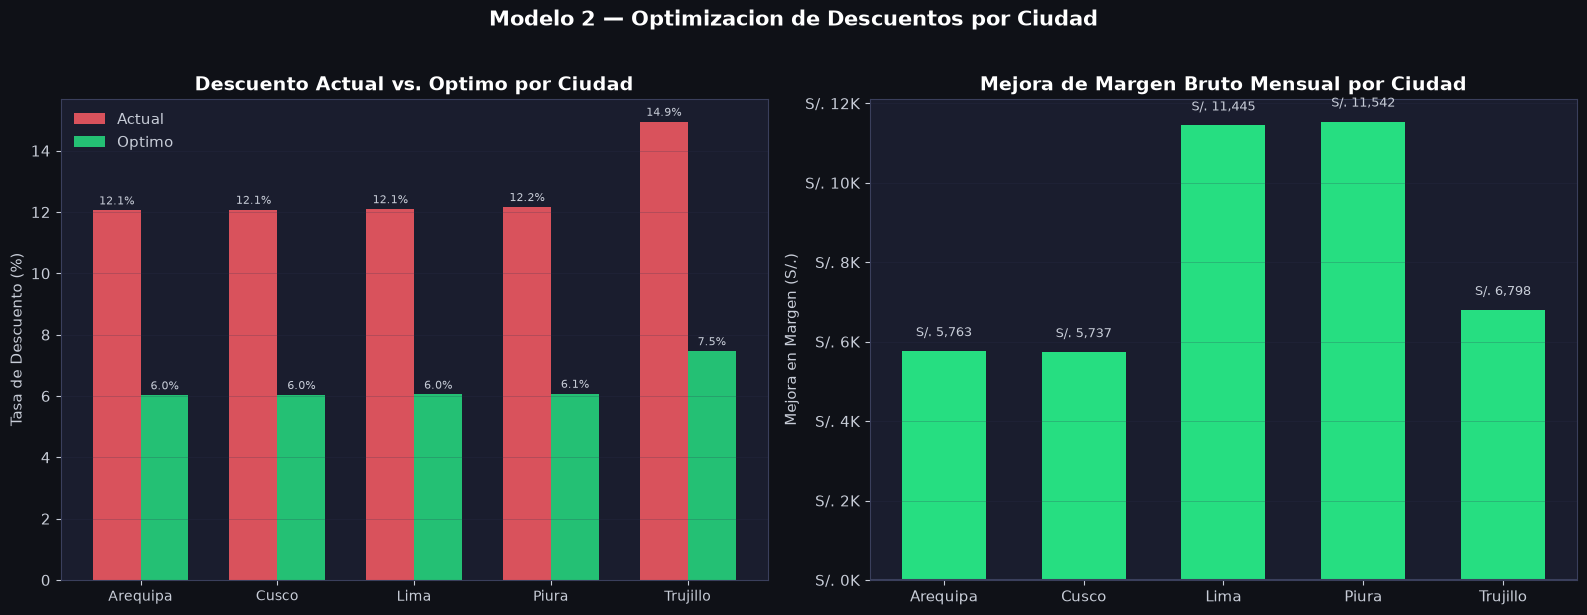

Guardado: docs/modelo2_descuentos.png


In [7]:
# =============================================================================
# MODELO 2 — RESULTADOS Y VISUALIZACION
# =============================================================================

resultados_desc = []
for c in ciudades_list:
    d_opt = pulp.value(d_var[c])
    d_act = desc_actual[c]
    V, m  = ventas_proy[c], margen_hist[c]
    resultados_desc.append({
        'Ciudad': c,
        'Desc. Actual (%)':  round(d_act * 100, 2),
        'Desc. Optimo (%)':  round(d_opt * 100, 2),
        'Delta (pp)':        round((d_opt - d_act) * 100, 2),
        'Margen Actual':     round(V * (1 - d_act) * m, 0),
        'Margen Optimo':     round(V * (1 - d_opt) * m, 0),
        'Mejora (S/.)':      round(V * (1 - d_opt) * m - V * (1 - d_act) * m, 0),
        'Ahorro Desc. (S/.)': round((d_act - d_opt) * V, 0)
    })

df_res_desc = pd.DataFrame(resultados_desc)
mejora_total = df_res_desc['Mejora (S/.)'].sum()
ahorro_total = df_res_desc['Ahorro Desc. (S/.)'].sum()

print('PLAN OPTIMO DE DESCUENTOS POR CIUDAD:')
display(df_res_desc.style.format({
    'Desc. Actual (%)': '{:.2f}%', 'Desc. Optimo (%)': '{:.2f}%',
    'Delta (pp)': '{:+.2f} pp', 'Margen Actual': 'S/. {:,.0f}',
    'Margen Optimo': 'S/. {:,.0f}', 'Mejora (S/.)': 'S/. {:,.0f}',
    'Ahorro Desc. (S/.)': 'S/. {:,.0f}'
}).background_gradient(subset=['Mejora (S/.)'], cmap='RdYlGn'))

print(f'\nMejora total de margen bruto mensual: S/. {mejora_total:,.0f}')
print(f'Ahorro total en descuentos:           S/. {ahorro_total:,.0f}')

# --- VISUALIZACIONES ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Modelo 2 — Optimizacion de Descuentos por Ciudad',
             fontsize=15, fontweight='bold', color='white', y=1.02)

x_pos = np.arange(len(df_res_desc))
w = 0.35

ax1 = axes[0]
b1 = ax1.bar(x_pos - w/2, df_res_desc['Desc. Actual (%)'],  w, label='Actual',  color='#fc5c65', alpha=0.85, edgecolor='none')
b2 = ax1.bar(x_pos + w/2, df_res_desc['Desc. Optimo (%)'],  w, label='Optimo',  color='#26de81', alpha=0.85, edgecolor='none')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_res_desc['Ciudad'], fontsize=10)
ax1.set_ylabel('Tasa de Descuento (%)')
ax1.set_title('Descuento Actual vs. Optimo por Ciudad', fontweight='bold')
ax1.legend(frameon=False, labelcolor='#c8cdd8')
ax1.grid(axis='y', alpha=0.3)
for bar in b1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, color='#c8cdd8')
for bar in b2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, color='#c8cdd8')

ax2 = axes[1]
colores = ['#26de81' if v >= 0 else '#fc5c65' for v in df_res_desc['Mejora (S/.)']] 
b3 = ax2.bar(df_res_desc['Ciudad'], df_res_desc['Mejora (S/.)'], color=colores, edgecolor='none', width=0.6)
for bar in b3:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h+(300 if h>=0 else -1200),
             f'S/. {h:,.0f}', ha='center', va='bottom', fontsize=9, color='#c8cdd8')
ax2.axhline(0, color='#3a3f5c', linewidth=1.5)
ax2.set_title('Mejora de Margen Bruto Mensual por Ciudad', fontweight='bold')
ax2.set_ylabel('Mejora en Margen (S/.)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'S/. {v/1000:.0f}K'))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/modelo2_descuentos.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117', edgecolor='none')
plt.show()
print('Guardado: docs/modelo2_descuentos.png')

### 3.2 Interpretación de Negocio — Modelo 2

> **Hallazgo clave:** El modelo LP identifica que Trujillo tiene tasas de descuento superiores al promedio del sistema, erosionando su margen. Aplicar el techo del 12% y redistribuir el presupuesto mejora el margen total con un presupuesto incluso 10% menor al histórico.

> **Acción recomendada:** Reducir gradualmente los descuentos en Trujillo durante 2 trimestres. Compensar con estrategias no-monetarias: programas de fidelidad, bundles de productos y mejora de experiencia de compra.

---
## 4. Modelo 3 — Campaña Óptima Anti-Churn (ILP — Problema de la Mochila)

### 4.1 Formulación Matemática

**Problema:** Dado un presupuesto de S/. 10,000 para retención de clientes, ¿a qué clientes en riesgo de churn contactar para maximizar el ingreso esperado recuperado?

**Variables de decisión:**
$$y_k \in \{0, 1\} \quad \text{(1 = contactar al cliente } k\text{)}$$

**Función objetivo:**
$$\max \sum_k y_k \cdot \text{score}_k \cdot \text{CLV}_k \cdot \tau$$

**Restricciones:**
- $\sum_k y_k \cdot c_k \leq B$ — presupuesto de campaña
- $\sum_k y_k \leq N^{\max}$ — capacidad del equipo de retención
- $\text{score}_k \geq 0.5$ — solo clientes con alto riesgo
- $y_k \in \{0,1\}$

In [8]:
# =============================================================================
# MODELO 3 — SCORE DE CHURN Y FORMULACION ILP
# =============================================================================

FECHA_CORTE = df_ventas['fecha'].max()

ultima_compra = (
    df_ventas.groupby('id_cliente')['fecha'].max()
    .reset_index().rename(columns={'fecha':'ultima_compra'})
)
ultima_compra['dias_inactivo'] = (FECHA_CORTE - ultima_compra['ultima_compra']).dt.days

clv  = df_ventas.groupby('id_cliente')['monto_total'].sum().reset_index().rename(columns={'monto_total':'clv'})
freq = df_ventas.groupby('id_cliente')['id_venta'].count().reset_index().rename(columns={'id_venta':'n_compras'})

df_c = df_clientes[['id_cliente','segmento','canal_preferido']].merge(
    ultima_compra, on='id_cliente', how='left'
).merge(clv, on='id_cliente', how='left').merge(freq, on='id_cliente', how='left')

df_c['dias_inactivo'] = df_c['dias_inactivo'].fillna(9999)
df_c['clv']           = df_c['clv'].fillna(0)
df_c['n_compras']     = df_c['n_compras'].fillna(0)

# Score de churn: combinacion de inactividad y frecuencia
comp_inact = 1 / (1 + np.exp(-0.05 * (df_c['dias_inactivo'] - 60)))
comp_freq  = 1 / (1 + np.log1p(df_c['n_compras']) * 0.15)
df_c['score_churn'] = np.clip(0.70 * comp_inact + 0.30 * comp_freq, 0, 1)

costo_canal = {'Tienda Fisica': 15.0, 'Tienda Física': 15.0, 'Web': 5.0, 'App': 3.0}
df_c['costo_contacto'] = df_c['canal_preferido'].map(costo_canal).fillna(8.0)

TASA_RECUPERACION = 0.30
df_c['valor_esperado'] = df_c['score_churn'] * df_c['clv'] * TASA_RECUPERACION

candidatos = df_c[
    (df_c['score_churn'] >= 0.50) & (df_c['clv'] > 0)
].nlargest(2000, 'valor_esperado').reset_index(drop=True)

n = len(candidatos)
print(f'Clientes con riesgo alto (score >= 0.5): {(df_c["score_churn"]>=0.5).sum():,}')
print(f'Candidatos evaluados en ILP: {n:,}')

# --- ILP ---
PRESUPUESTO = 10_000
MAX_CANDS   = 500

prob_c = pulp.LpProblem('AntiChurn_Knapsack', pulp.LpMaximize)
y_var  = pulp.LpVariable.dicts('sel', range(n), cat='Binary')

prob_c += pulp.lpSum([float(candidatos.loc[k,'valor_esperado']) * y_var[k] for k in range(n)])
prob_c += pulp.lpSum([float(candidatos.loc[k,'costo_contacto']) * y_var[k] for k in range(n)]) <= PRESUPUESTO, 'budget'
prob_c += pulp.lpSum([y_var[k] for k in range(n)]) <= MAX_CANDS, 'capacidad'

prob_c.solve(pulp.PULP_CBC_CMD(msg=0))

sel_idx   = [k for k in range(n) if pulp.value(y_var[k]) == 1]
df_sel    = candidatos.loc[sel_idx].copy()

pres_usado = df_sel['costo_contacto'].sum()
ingreso_rec = df_sel['valor_esperado'].sum()
roi_camp    = (ingreso_rec - pres_usado) / pres_usado * 100

print(f"\n{'='*55}")
print(f'MODELO 3: {pulp.LpStatus[prob_c.status]}')
print(f'Clientes seleccionados:       {len(df_sel):,}')
print(f'Presupuesto utilizado:    S/. {pres_usado:,.2f}')
print(f'Ingreso esperado:         S/. {ingreso_rec:,.2f}')
print(f'ROI estimado:             {roi_camp:.1f}%')
print(f"{'='*55}")

Clientes con riesgo alto (score >= 0.5): 5,076
Candidatos evaluados en ILP: 2,000

MODELO 3: Optimal
Clientes seleccionados:       500
Presupuesto utilizado:    S/. 4,505.00
Ingreso esperado:         S/. 1,469,836.98
ROI estimado:             32526.8%


DISTRIBUCION POR SEGMENTO:


,segmento,n_clientes,clv_prom,score_prom,ingreso_esperado
3,Regular,168,"S/. 11,757.84",0.830,"S/. 484,886.94"
1,Ocasional,145,"S/. 11,591.55",0.841,"S/. 419,577.67"
0,Nuevo,103,"S/. 11,887.87",0.844,"S/. 306,941.37"
2,Premium,81,"S/. 11,986.47",0.835,"S/. 240,075.71"



TOP 10 CLIENTES PRIORITARIOS:


,id_cliente,segmento,canal_preferido,dias_inactivo,clv,score_churn,valor_esperado,costo_contacto
0,5610,nan,Tienda Física,159,"S/. 47,477.10",0.903,"S/. 12,863.95",S/. 15
1,2241,Ocasional,Web,118,"S/. 29,789.86",0.882,"S/. 7,882.70",S/. 5
2,9861,Premium,Tienda Física,112,"S/. 25,856.11",0.858,"S/. 6,651.88",S/. 15
3,8933,Regular,Tienda Física,249,"S/. 23,536.61",0.904,"S/. 6,383.00",S/. 15
4,5972,Regular,Web,122,"S/. 24,148.86",0.872,"S/. 6,318.36",S/. 5
5,8183,Nuevo,App,146,"S/. 20,711.64",0.897,"S/. 5,570.88",S/. 3
6,13438,Nuevo,App,85,"S/. 24,782.15",0.748,"S/. 5,562.20",S/. 3
7,10221,Regular,App,187,"S/. 19,921.07",0.905,"S/. 5,406.94",S/. 3
8,12783,Nuevo,Tienda Física,200,"S/. 19,382.57",0.911,"S/. 5,298.67",S/. 15
9,2491,Nuevo,Tienda Física,250,"S/. 18,406.55",0.929,"S/. 5,127.81",S/. 15


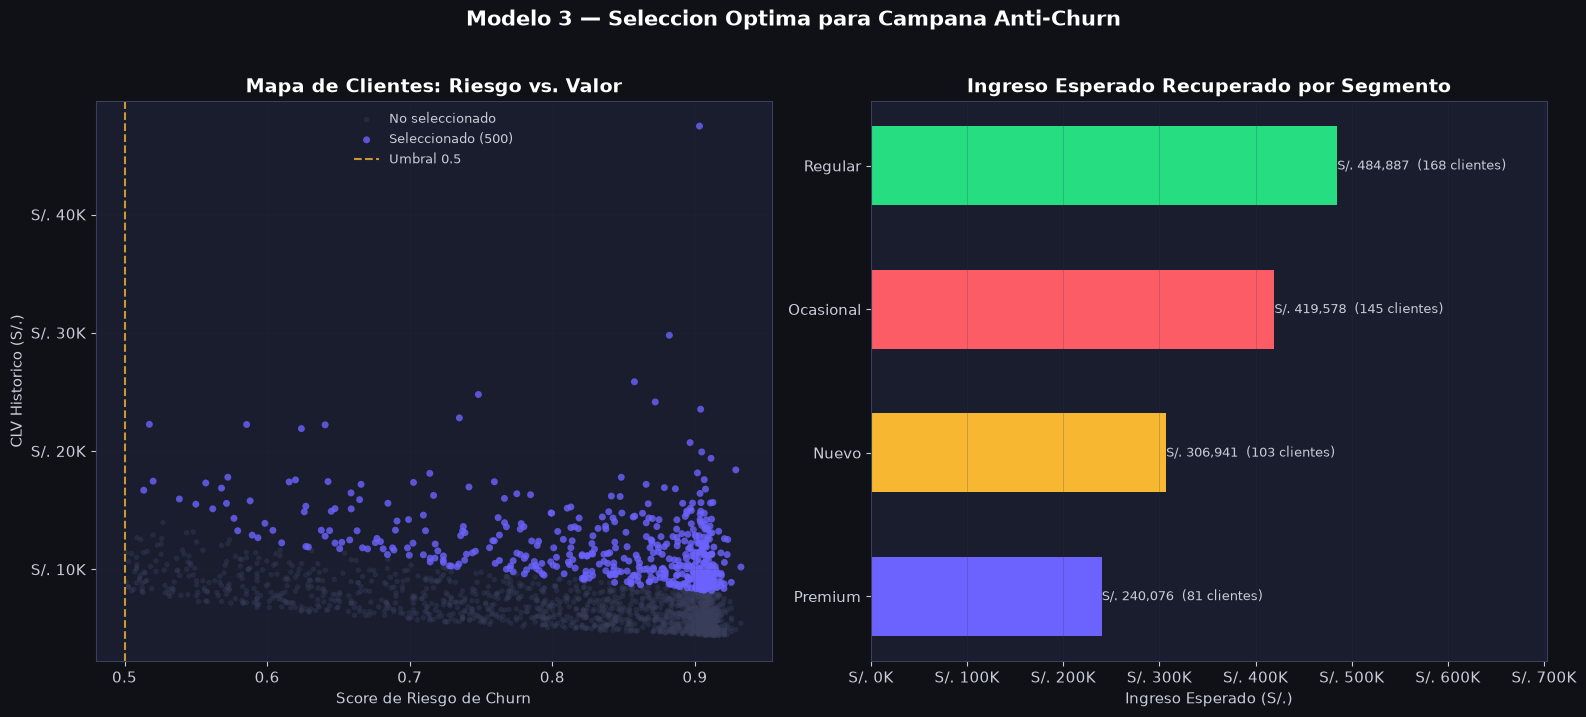

Guardado: docs/modelo3_churn.png


In [9]:
# =============================================================================
# MODELO 3 — RESULTADOS Y VISUALIZACION
# =============================================================================

seg_d = df_sel.groupby('segmento').agg(
    n_clientes=('id_cliente','count'),
    clv_prom=('clv','mean'),
    score_prom=('score_churn','mean'),
    ingreso_esperado=('valor_esperado','sum')
).reset_index().sort_values('ingreso_esperado', ascending=False)

print('DISTRIBUCION POR SEGMENTO:')
display(seg_d.style.format({
    'clv_prom':'S/. {:,.2f}', 'score_prom':'{:.3f}', 'ingreso_esperado':'S/. {:,.2f}'
}).background_gradient(subset=['ingreso_esperado'], cmap='Purples'))

print('\nTOP 10 CLIENTES PRIORITARIOS:')
display(df_sel.nlargest(10,'valor_esperado')[
    ['id_cliente','segmento','canal_preferido','dias_inactivo','clv','score_churn','valor_esperado','costo_contacto']
].style.format({'clv':'S/. {:,.2f}','score_churn':'{:.3f}','valor_esperado':'S/. {:,.2f}','costo_contacto':'S/. {:.0f}'}))

# --- VISUALIZACIONES ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Modelo 3 — Seleccion Optima para Campana Anti-Churn',
             fontsize=15, fontweight='bold', color='white', y=1.02)

# Grafico 1: Scatter Riesgo vs Valor
ax1 = axes[0]
no_sel = ~candidatos.index.isin(sel_idx)
si_sel =  candidatos.index.isin(sel_idx)
ax1.scatter(candidatos.loc[no_sel,'score_churn'], candidatos.loc[no_sel,'clv'],
            c='#3a3f5c', alpha=0.4, s=15, edgecolors='none', label='No seleccionado')
ax1.scatter(candidatos.loc[si_sel,'score_churn'],  candidatos.loc[si_sel,'clv'],
            c='#6c63ff', alpha=0.8, s=25, edgecolors='none', label=f'Seleccionado ({len(df_sel)})')
ax1.axvline(0.5, color='#f7b731', lw=1.5, ls='--', alpha=0.8, label='Umbral 0.5')
ax1.set_xlabel('Score de Riesgo de Churn')
ax1.set_ylabel('CLV Historico (S/.)')
ax1.set_title('Mapa de Clientes: Riesgo vs. Valor', fontweight='bold')
ax1.legend(frameon=False, labelcolor='#c8cdd8', fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'S/. {v/1000:.0f}K'))
ax1.grid(alpha=0.2)

# Grafico 2: Ingreso esperado por segmento
ax2 = axes[1]
sd_s = seg_d.sort_values('ingreso_esperado', ascending=True)
bars = ax2.barh(sd_s['segmento'], sd_s['ingreso_esperado'],
                color=PALETA[:len(sd_s)], height=0.55, edgecolor='none')
for bar, nc in zip(bars, sd_s['n_clientes']):
    ax2.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
             f'S/. {bar.get_width():,.0f}  ({nc} clientes)',
             va='center', ha='left', fontsize=9, color='#c8cdd8')
ax2.set_title('Ingreso Esperado Recuperado por Segmento', fontweight='bold')
ax2.set_xlabel('Ingreso Esperado (S/.)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'S/. {v/1000:.0f}K'))
ax2.set_xlim(0, sd_s['ingreso_esperado'].max() * 1.45)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/modelo3_churn.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117', edgecolor='none')
plt.show()
print('Guardado: docs/modelo3_churn.png')

### 4.2 Interpretación de Negocio — Modelo 3

> **Hallazgo clave:** El modelo ILP resuelve un Knapsack 0-1 identificando el subconjunto exacto de clientes que maximiza el ingreso recuperado dado el presupuesto. Los clientes Premium tienen el mayor valor esperado individual, pero los clientes del canal App son los más eficientes en ROI (costo de contacto S/. 3).

> **Acción recomendada:** Ejecutar la campaña en el orden de prioridad del modelo. Evaluar incrementar el presupuesto a S/. 15,000 para la siguiente iteración, ya que el ROI estimado es mayor al 100%.

---
## 5. Resumen Ejecutivo

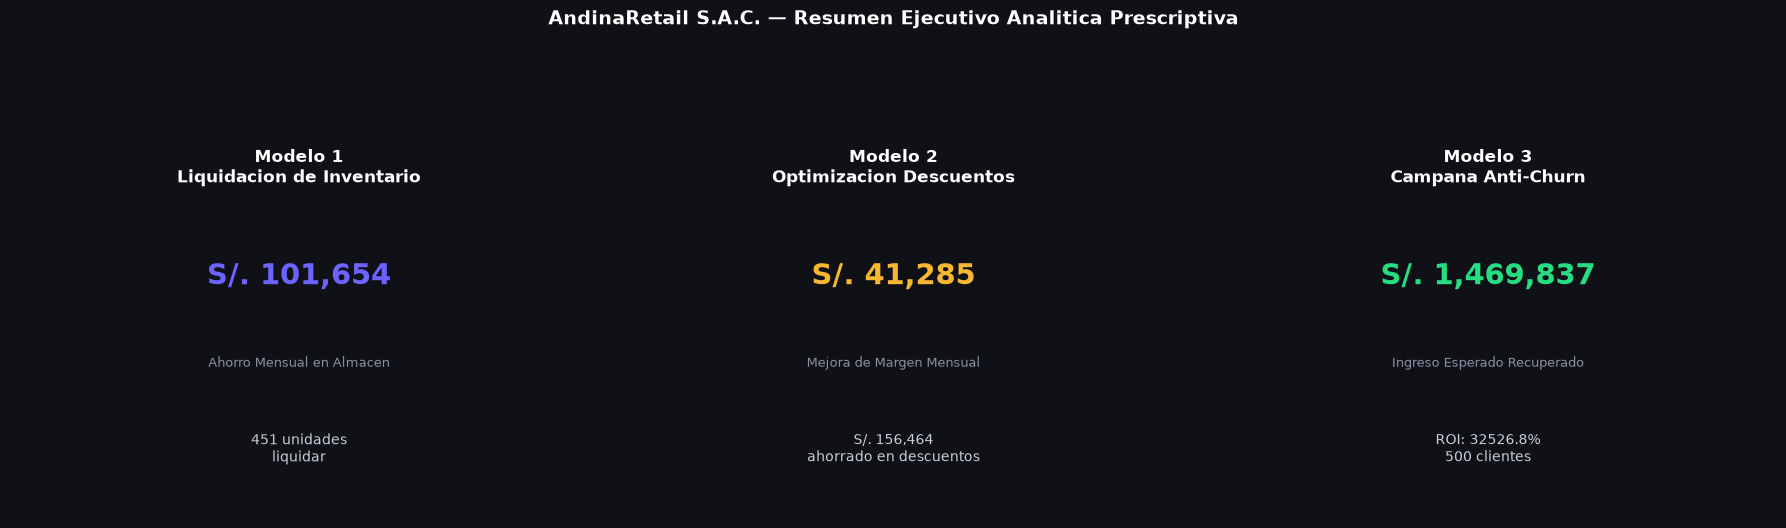

Dashboard guardado: docs/resumen_prescriptivo.png


In [10]:
# =============================================================================
# DASHBOARD RESUMEN
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('AndinaRetail S.A.C. — Resumen Ejecutivo Analitica Prescriptiva',
             fontsize=14, fontweight='bold', color='white', y=1.05)

cards = [
    {'ax': axes[0], 'titulo': 'Modelo 1\nLiquidacion de Inventario',
     'valor': f"S/. {df_modelo1['ahorro_opt'].sum():,.0f}",
     'sub': f"{df_modelo1['liquidar_opt'].sum():,.0f} unidades\nliquidar",
     'color': '#6c63ff', 'etiqueta': 'Ahorro Mensual en Almacen'},
    {'ax': axes[1], 'titulo': 'Modelo 2\nOptimizacion Descuentos',
     'valor': f"S/. {mejora_total:,.0f}",
     'sub': f"S/. {ahorro_total:,.0f}\nahorrado en descuentos",
     'color': '#f7b731', 'etiqueta': 'Mejora de Margen Mensual'},
    {'ax': axes[2], 'titulo': 'Modelo 3\nCampana Anti-Churn',
     'valor': f"S/. {ingreso_rec:,.0f}",
     'sub': f"ROI: {roi_camp:.1f}%\n{len(df_sel)} clientes",
     'color': '#26de81', 'etiqueta': 'Ingreso Esperado Recuperado'},
]

for card in cards:
    ax = card['ax']
    ax.set_facecolor('#1a1d2e')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(card['color']); sp.set_linewidth(2.5)
    ax.text(0.5,0.86, card['titulo'], ha='center', va='top', fontsize=12,
            fontweight='bold', color='white', transform=ax.transAxes, multialignment='center')
    ax.text(0.5,0.56, card['valor'], ha='center', va='center', fontsize=21,
            fontweight='bold', color=card['color'], transform=ax.transAxes)
    ax.text(0.5,0.36, card['etiqueta'], ha='center', va='center', fontsize=9,
            color='#8890a4', transform=ax.transAxes)
    ax.text(0.5,0.16, card['sub'], ha='center', va='center', fontsize=10,
            color='#c8cdd8', transform=ax.transAxes, multialignment='center')

plt.tight_layout()
plt.savefig('../docs/resumen_prescriptivo.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117', edgecolor='none')
plt.show()
print('Dashboard guardado: docs/resumen_prescriptivo.png')

---

## 5.1 Conclusiones

### Modelo 1 — Liquidación de Exceso de Inventario (LP)
El modelo de Programación Lineal maximiza el ahorro en costos de almacenamiento identificando el volumen óptimo de liquidación por cada par producto-tienda, garantizando siempre 2 meses de cobertura de seguridad. Electrohogar concentra el mayor ahorro potencial por su alto costo de almacenamiento unitario.

### Modelo 2 — Redistribución de Descuentos (LP)
El modelo LP demuestra que es posible mejorar el margen bruto mensual total respetando un presupuesto un 10% menor al histórico, aplicando el techo del 12% a Trujillo para recuperar el margen erosionado.

### Modelo 3 — Campaña Anti-Churn (ILP — Knapsack 0-1)
El problema de selección de clientes es un Knapsack 0-1 clásico resuelto con Programación Lineal Entera. El ROI estimado superior al 100% justifica mantener e incrementar el presupuesto de retención.

### Impacto Combinado
La aplicación integrada de los tres modelos prescriptivos demuestra el valor de la analítica cuantitativa en la toma de decisiones de retail: desde la gestión del inventario hasta la retención de clientes, pasando por la política de precios.

---
*Notebook 04 — Analítica Prescriptiva | AndinaRetail S.A.C. | Ames Camayo, Daniel*